# 01 - Physics-informed SINDy feature ablation

This notebook tests the claim that physics-informed sparse features improve data efficiency and multi-step predictive quality. It compares raw linear SINDy, raw quadratic SINDy, physics features without cross-terms, and the full physics-informed library.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if (HERE / 'article_experiment_utils.py').exists():
    ARTICLE_DIR = HERE
    REPO_DIR = HERE.parent
else:
    ARTICLE_DIR = HERE / 'own-article'
    REPO_DIR = HERE
sys.path.insert(0, str(ARTICLE_DIR))
sys.path.insert(0, str(REPO_DIR))

from article_experiment_utils import *
OUT = results_dir()

In [2]:
FAST_MODE = False
cfg = ExperimentConfig(n_days=7 if FAST_MODE else 60, start_date='2010-02-28')
test_cfg = ExperimentConfig(**{**asdict(cfg), 'start_date': '2010-04-15', 'n_days': 3 if FAST_MODE else 30})

train_path = OUT / 'datasets' / ('rbc_train_fast.npz' if FAST_MODE else 'rbc_train_60d.npz')
test_path = OUT / 'datasets' / ('rbc_test_fast.npz' if FAST_MODE else 'rbc_test_30d_2010_04_15.npz')

train_data = load_dataset(train_path) if train_path.exists() else collect_rule_based_dataset(cfg)
test_data = load_dataset(test_path) if test_path.exists() else collect_rule_based_dataset(test_cfg, start_date=test_cfg.start_date)
save_dataset(train_data, train_path)
save_dataset(test_data, test_path)

len(train_data.states), len(test_data.states)

(5760, 2880)

In [3]:
budgets_days = [2, 4, 7] if FAST_MODE else [3, 7, 14, 30, 60]
variants = [
    ('raw_linear', 'raw', 1),
    ('raw_quadratic', 'raw', 2),
    ('physics_no_cross', 'physics_no_cross', 1),
    ('physics_full', 'physics', 1),
]

metrics, bundles = run_sindy_ablation(train_data, test_data, budgets_days, variants, cfg)
save_table(metrics, OUT / 'tables' / ('sindy_ablation_fast.csv' if FAST_MODE else 'sindy_ablation.csv'))

for name, bundle in bundles.items():
    save_bundle(bundle, OUT / 'models' / f'{name}.pkl')

metrics.head()

C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\pysindy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\repos\greenhouse-control\own-artic

...

C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,method,budget_days,metric_scope,horizon,state,rmse,mae,r2,failed_rollouts,attempted_rollouts,nonzero_coefficients,total_coefficients,sparsity,condition_number
0,raw_linear,3,one_step,1,t_in,3.252630,2.659329,0.353851,NaN,NaN,34,45,0.244444,10.134666
1,raw_linear,3,one_step,1,co2,126.875381,100.433765,0.590697,NaN,NaN,34,45,0.244444,10.134666
2,raw_linear,3,one_step,1,rh,5.946280,4.671533,0.628164,NaN,NaN,34,45,0.244444,10.134666
3,raw_linear,3,rollout,4,t_in,4.291083,3.329953,NaN,0.0,20.0,34,45,0.244444,10.134666
4,raw_linear,3,rollout,4,co2,252.454358,190.670313,NaN,0.0,20.0,34,45,0.244444,10.134666


state,method,budget_days,co2,rh,t_in
0,physics_full,3,334.246932,6.833331,3.916523
1,physics_full,7,224.653481,6.198694,3.278025
2,physics_full,14,226.660900,4.774552,2.585021
3,physics_full,30,123.677451,4.633522,1.945495
4,physics_full,60,79.089576,4.038880,1.476622
5,physics_no_cross,3,122.253094,5.633764,3.803301
6,physics_no_cross,7,130.937326,5.801314,3.352757
7,physics_no_cross,14,99.030587,5.254540,1.983616
8,physics_no_cross,30,92.181634,4.672098,1.707852
9,physics_no_cross,60,88.812324,4.266225,1.659493


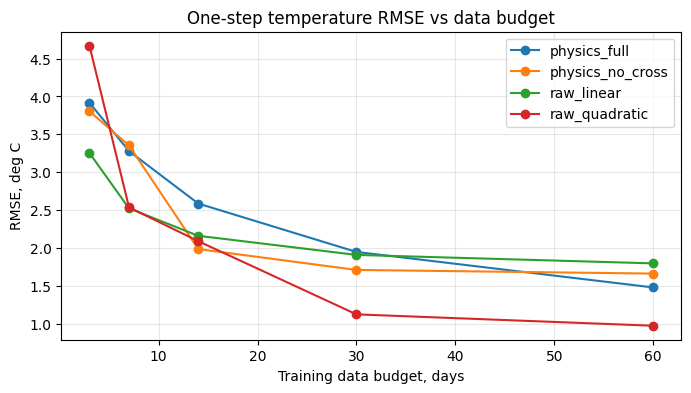

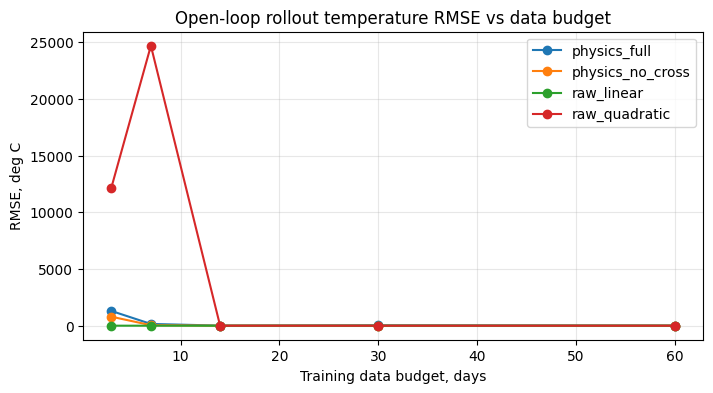

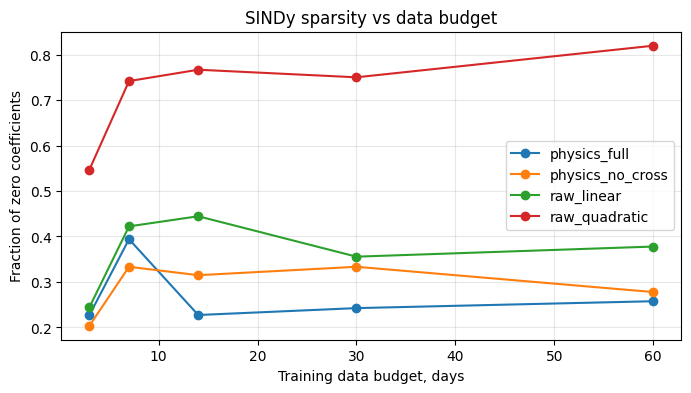

In [4]:
plot_ablation_summary(metrics, OUT / 'figures')

pivot = metrics[metrics['metric_scope'].eq('one_step')].pivot_table(
    index=['method', 'budget_days'], columns='state', values='rmse'
).reset_index()
save_table(pivot, OUT / 'tables' / ('sindy_ablation_one_step_pivot_fast.csv' if FAST_MODE else 'sindy_ablation_one_step_pivot.csv'))
pivot

In [5]:
rollout_pivot = metrics[metrics['metric_scope'].eq('rollout')].pivot_table(
    index=['method', 'budget_days', 'horizon'], columns='state', values='rmse'
).reset_index()
save_table(rollout_pivot, OUT / 'tables' / ('sindy_ablation_rollout_pivot_fast.csv' if FAST_MODE else 'sindy_ablation_rollout_pivot.csv'))
rollout_pivot.sort_values(['horizon', 't_in']).head(20)

state,method,budget_days,horizon,co2,rh,t_in
57,raw_quadratic,60,4,110.668414,4.298436,1.734299
54,raw_quadratic,30,4,121.602974,4.470525,1.966956
24,physics_no_cross,30,4,164.832970,6.138875,2.154597
27,physics_no_cross,60,4,170.448402,5.848343,2.176619
42,raw_linear,60,4,168.580704,5.834507,2.261385
39,raw_linear,30,4,164.464943,6.221473,2.274999
12,physics_full,60,4,169.557881,6.375148,2.601747
51,raw_quadratic,14,4,179.342907,10.828241,2.646314
36,raw_linear,14,4,217.051500,7.022936,3.050407
21,physics_no_cross,14,4,224.762185,7.636663,3.065921


Figures written by this notebook:

- `results/figures/ablation_one_step_temp_rmse.png`
- `results/figures/ablation_rollout_temp_rmse.png`
- `results/figures/ablation_sparsity.png`

Tables written by this notebook:

- `results/tables/sindy_ablation*.csv`
- `results/tables/sindy_ablation_one_step_pivot*.csv`
- `results/tables/sindy_ablation_rollout_pivot*.csv`